# 通过脉冲序列生成等效OAT模型和TAT模型
《Dynamic synthesis of Heisenberg-limited spin squeezing》

In [98]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from tqdm import tqdm
from scipy.stats import binom
from IPython.display import HTML
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.formatter.use_mathtext'] = True 
plt.rcParams['mathtext.fontset'] = 'cm'

## 理论计算推导
### 合成OAT模型
在本方案中，我们有两个自旋子系统S和J，子系统J是辅助子系统，通过两个系统之间的相互作用，来帮助子系统S实现自旋压缩。系统的哈密顿量为：
$$ H_{int} = g S_z J_z $$
这是相互作用绘景下的哈密顿量，通过绘景变换去除了与相互作用无关的自由项（如$S_z, J_z$项），剩下$S_z^2, S_zJ_z,J_z^2$这些项。而在特定的一些系统中，$S_z^2, J_z^2$会消失，只剩下$S_zJ_z$项。

集体自旋算符为：
$$ \begin{align*}
S_{\mu} = \frac{1}{2} \sum_{n=1}^{N_s} \sigma_{S, \mu}^{(n)} \\
J_{\mu} = \frac{1}{2} \sum_{n=1}^{N_j} \sigma_{J, \mu}^{(n)}
\end{align*} \quad , \mu = x, y, z
$$



我们在子系统J上施加周期性的$\frac{\pi}{2}$脉冲序列，让J在一个周期内完成一次绕x轴的旋转。我们的初始条件是x轴正方向上的自旋相干态。相互作用系统的哈密顿量可以表示为：
$$H = \begin{cases}
g S_z J_z ,\quad t\mod t_c \in (0, \tau - \delta t) \cup (\tau, 2\tau - \delta t) \cup (2\tau, 3\tau - \delta t) \cup (3\tau, 4\tau-\delta t) \\
\Omega J_x+g S_z J_z ,\quad t\mod t_c \in (\tau - \delta t, \tau) \cup (2\tau-\delta t, 2\tau) \cup (3\tau-\delta t, 3\tau) \cup (4\tau-\delta t, 4\tau) 
\end{cases}
$$
其中$t_c$为一个周期，$\tau$是单次自由演化的时间长度，$\delta t$是一次很短的脉冲时长，满足$\delta t \cdot\Omega = \frac{\pi}{2}$。该哈密顿量表示，在一个周期中，首先让系统自由演化一段时间$\tau$，然后让J绕x轴旋转$\frac{\pi}{2}$，重复此过程，以四次重复为一个周期。一个周期的时间演化算符为：
$$
\begin{align*}
U(t_c) &=(e^{-i\frac{\pi}{2}J_x}e^{-igS_zJ_z\tau})^4\\
&= e^{-i\frac{\pi}{2}J_x}e^{-igS_zJ_z\tau}e^{-i\frac{\pi}{2}J_x}e^{-igS_zJ_z\tau}e^{-i\frac{\pi}{2}J_x}e^{-igS_zJ_z\tau}e^{-i\frac{\pi}{2}J_x}e^{-igS_zJ_z\tau}\\
&= R U R U R U R U \\
&= R \cdot U \cdot (R^{-1} R) \cdot U \cdot (R^{-2} R^2) \cdot U \cdot (R^{-3} R^3) \cdot U \cdot (R^{-4} R^4) \quad \text{插入单位阵技巧}\\
&= (R U R^{-1}) \cdot (R^2 U R^{-2}) \cdot (R^3 U R^{-3}) \cdot (R^4 U R^{-4}) \cdot R^4 \qquad \quad \text{利用了$Ae^BA^{-1}=e^{ABA^{-1}}$}\\
&= e^{igS_zJ_y\tau} e^{igS_zJ_z\tau} e^{-igS_zJ_y\tau} e^{-igS_zJ_z\tau} \cdot R^4\\
&= e^{igS_zJ_y\tau} e^{igS_zJ_z\tau} e^{-igS_zJ_y\tau} e^{-igS_zJ_z\tau} = \prod_{k=1}^4 \mathcal{U}_k\\
&=e^A e^B e^{-A} e^{-B}\\
&=e^{A+B+\frac{1}{2}[A,B]+…}e^{-A-B+\frac{1}{2}[A,B]+…} \qquad \text{使用BCH公式}\\
&\approx e^{[A,B]} \\
&=e^{-g^2\tau^2 S_z^2 [J_y, J_z]}\\
&=e^{-ig^2 S_z^2 J_x \tau^2}
\end{align*}
$$
子系统J处在x正方向的自旋相干态时，$J_x$的本征值为$\frac{N_j}{2}$，$\delta t$极短因此$U(4\tau) = U(t_c) = e^{-ig^2 S_z^2 J_x \tau^2}$，即$U(t) = e^{-i\frac{g^2 N_j \tau}{8} S_z^2  t}$，于是有效哈密顿量为$H^{eff} = \frac{g^2 N_j \tau}{8} S_z^2$，等效为OAT模型$H_{OAT} = \chi S_z^2$，相互作用强度$\chi = \frac{g^2 N_j \tau}{8}$


### 合成TAT模型
为了合成TAT模型，我们采取以下的脉冲序列方案：

对子系统J，先自由演化时间$\tau$，然后施加一个绕x轴旋转$\frac{\pi}{2}$的脉冲，再重复此过程3次。接着自由演化时间$\tau$，然后施加一个绕x轴旋转$-\frac{\pi}{2}$的脉冲，重复此过程3次。忽略脉冲时间$\delta t$，一个周期总长度为$8\tau$；

对子系统S，我们在子系统J第4次绕x轴旋转$\frac{\pi}{2}$的时候，让S绕x轴旋转$-\frac{\pi}{2}$。在子系统J第4次绕x轴旋转$-\frac{\pi}{2}$的时候，让S绕x轴旋转$\frac{\pi}{2}$

哈密顿量可以表示为：
$$H = gS_zJ_z + \Omega_1(t)J_x + \Omega_2(t)S_x$$
其中：
$$\Omega_1(t) = 
\begin{cases}
\frac{\pi}{2\delta t}, \quad t\mod t_c \in (\tau - \delta t, \tau) \cup (2\tau-\delta t, 2\tau) \cup (3\tau-\delta t, 3\tau) \cup (4\tau-\delta t, 4\tau)\\
-\frac{\pi}{2\delta t}, \quad t\mod t_c \in (5\tau - \delta t, 5\tau) \cup (6\tau-\delta t, 6\tau) \cup (7\tau-\delta t, 7\tau) \cup (8\tau-\delta t, 8\tau)
\end{cases}
$$
$$\Omega_2(t) = 
\begin{cases}
\frac{\pi}{2\delta t}, \quad t\mod t_c \in (4\tau-\delta t, 4\tau)\\
-\frac{\pi}{2\delta t}, \quad t\mod t_c \in (8\tau-\delta t, 8\tau)
\end{cases}
$$

一个周期内的时间演化算符为：
$$ \begin{align*}
U(t_c) &= U(8\tau) \\
&= e^{-i\frac{\pi}{2}S_x} (e^{i\frac{\pi}{2}J_x}e^{-igS_zJ_z\tau})^4 e^{i\frac{\pi}{2}S_x} (e^{-i\frac{\pi}{2}J_x}e^{-igS_zJ_z\tau})^4\\
&\approx (e^{-i\frac{\pi}{2}S_x} e^{ig^2 S_z^2 J_x \tau^2} e^{i\frac{\pi}{2}S_x}) e^{-ig^2 S_z^2 J_x \tau^2} \quad \text{由之前合成OAT的计算结果可得}\\
&=e^{i g^2 S_y^2 J_x \tau^2} e^{-ig^2 S_z^2 J_x \tau^2} \qquad \text{利用了$Ae^BA^{-1}=e^{ABA^{-1}}$}\\
&\approx e^{-ig^2 (S_z^2 - S_y^2) J_x \tau^2} \qquad \text{使用BCH公式并略去高阶小}
\end{align*}
$$
于是$U(t) \approx e^{-i\frac{g^2 (S_z^2 - S_y^2) N_j \tau }{16}t}$，有效哈密顿量为$H^{eff} = \frac{g^2 (S_z^2 - S_y^2) N_j \tau }{16}$，可以等效为TAT模型，相互作用强度$\chi = \frac{g^2 N_j \tau }{16}$

## 数值模拟计算

### 合成OAT模型

#### 生成量子态

In [99]:
def custom_spin_coherent(j, theta, phi):
    """
    使用解析公式高效生成自旋相干态，比使用QuTiP自带的spin_coherent更高效
    """
    N = int(2 * j)
    i = np.arange(N + 1)
    p = np.sin(theta / 2)**2
    prob_m = binom.pmf(i, N, p)
    amp = np.sqrt(prob_m)
    phase = np.exp(1j * i * phi)
    vec = amp * phase
    return Qobj(vec).unit()

In [100]:
N_j = 100
N_s = 100
j_j = N_j / 2
j_s = N_s / 2
psi_0_j = custom_spin_coherent(j_j, np.pi / 2, 0)
psi_0_s = custom_spin_coherent(j_s, np.pi / 2, 0)
psi_0 = tensor(psi_0_j, psi_0_s)

#### 生成角动量算符

In [101]:
J_z = tensor(jmat(j_j, 'z'), qeye(N_s + 1))
S_z = tensor(qeye(N_j + 1), jmat(j_s, 'z'))
J_x = tensor(jmat(j_j, 'x'), qeye(N_s + 1))
S_x = tensor(qeye(N_j + 1), jmat(j_s, 'x'))
J_y = tensor(jmat(j_j, 'y'), qeye(N_s + 1))
S_y = tensor(qeye(N_j + 1), jmat(j_s, 'y'))

#### 生成哈密顿量

In [116]:
g = 1
t_max = 1
periods = 200  # 这里的periods就是pulses
tau = t_max / periods
# pulses = 4 * periods
t_num = 10 * periods
t_list = np.linspace(0, t_max, t_num)
t_min_interval = t_max / t_num
scale = 1
delta_t = t_min_interval * scale
Omega = np.pi / (2 * delta_t)
chi = g**2 * N_j * tau / 8

def f_1(t, args):
    t_mod = t % tau
    if t_mod >= tau - delta_t - 1e-10 or t_mod < 1e-10:
        return Omega
    else:
        return 0
H = [g * S_z * J_z, [J_x, f_1]]

#### 进行时间演化

In [103]:
result = mesolve(H, psi_0, t_list, c_ops=[], e_ops=[S_x, S_y, S_z, S_x*S_x, S_y*S_y, S_z*S_z, S_x*S_y+S_y*S_x, S_y*S_z+S_z*S_y, S_z*S_x+S_x*S_z],
                options={"store_states": True,
                         "nsteps": 10000,
                         "atol": 1e-9,
                         "rtol": 1e-9,
                         "max_step": t_min_interval})  # 默认情况下，求解器是自适应的，有可能直接跨过脉冲时间点。因此需要将max_step设置为最短时间间隔


#### 读取结果，并计算压缩参数

In [104]:
Sx_exp, Sy_exp, Sz_exp, Sx2_exp, Sy2_exp, Sz2_exp, Sxy_exp, Syz_exp, Szx_exp = result.expect
exp_Sx = Sx_exp
exp_Sy = Sy_exp
exp_Sz = Sz_exp
Cov_xx = Sx2_exp - Sx_exp * Sx_exp
Cov_yy = Sy2_exp - Sy_exp * Sy_exp
Cov_zz = Sz2_exp - Sz_exp * Sz_exp
Cov_xy = 1/2 * Sxy_exp - Sx_exp * Sy_exp
Cov_yz = 1/2 * Syz_exp - Sy_exp * Sz_exp
Cov_zx = 1/2 * Szx_exp - Sz_exp * Sx_exp
exp_J = np.sqrt(Sx_exp**2 + Sy_exp**2 + Sz_exp**2)
def calculate_Vmin_dynamics(exp_Jx, exp_Jy, exp_Jz, Cov_xx, Cov_yy, Cov_zz, Cov_xy, Cov_yz, Cov_zx):
    """
    输入参数全都是长度为 T 的 numpy 1D array (对应演化时间 tlist)
    """
    T = len(exp_Jx)
    R = np.sqrt(exp_Jx**2 + exp_Jy**2 + exp_Jz**2)
    n0 = np.zeros((T, 3, 1))
    n0[:, 0, 0] = exp_Jx / R
    n0[:, 1, 0] = exp_Jy / R
    n0[:, 2, 0] = exp_Jz / R
    I = np.eye(3).reshape(1, 3, 3)
    n0T = np.transpose(n0, axes=(0, 2, 1))
    P = I - np.matmul(n0, n0T)
    Sigma = np.zeros((T, 3, 3))
    Sigma[:, 0, 0] = Cov_xx
    Sigma[:, 1, 1] = Cov_yy
    Sigma[:, 2, 2] = Cov_zz
    Sigma[:, 0, 1] = Sigma[:, 1, 0] = Cov_xy
    Sigma[:, 1, 2] = Sigma[:, 2, 1] = Cov_yz
    Sigma[:, 0, 2] = Sigma[:, 2, 0] = Cov_zx
    Sigma_tilde = np.matmul(P, np.matmul(Sigma, P))
    tr_Sigma = np.trace(Sigma_tilde, axis1=1, axis2=2)
    Sigma_tilde_sq = np.matmul(Sigma_tilde, Sigma_tilde)
    tr_Sigma_sq = np.trace(Sigma_tilde_sq, axis1=1, axis2=2)
    V_min = 0.5 * (tr_Sigma - np.sqrt(np.abs(2 * tr_Sigma_sq - tr_Sigma**2)))
    return V_min

V_min = calculate_Vmin_dynamics(exp_Sx, exp_Sy, exp_Sz, Cov_xx, Cov_yy, Cov_zz, Cov_xy, Cov_yz, Cov_zx)


与相应的OAT模型进行对比

In [118]:
s_z = jmat(j_s, 'z')
s_x = jmat(j_s, 'x')
s_y = jmat(j_s, 'y')
H = chi * s_z * s_z
result_OAT = mesolve(H, psi_0_s, t_list, c_ops=[], e_ops=[s_x, s_y, s_z, s_x*s_x, s_y*s_y, s_z*s_z, s_x*s_y+s_y*s_x, s_y*s_z+s_z*s_y, s_z*s_x+s_x*s_z], options={"store_states": True})
Sx_exp_OAT, Sy_exp_OAT, Sz_exp_OAT, Sx2_exp_OAT, Sy2_exp_OAT, Sz2_exp_OAT, Sxy_exp_OAT, Syz_exp_OAT, Szx_exp_OAT = result_OAT.expect
exp_Sx_OAT = Sx_exp_OAT
Cov_xx_OAT = Sx2_exp_OAT - Sx_exp_OAT * Sx_exp_OAT
Cov_yy_OAT = Sy2_exp_OAT - Sy_exp_OAT * Sy_exp_OAT
Cov_zz_OAT = Sz2_exp_OAT - Sz_exp_OAT * Sz_exp_OAT
Cov_xy_OAT = 1/2 * Sxy_exp_OAT - Sx_exp_OAT * Sy_exp_OAT
Cov_yz_OAT = 1/2 * Syz_exp_OAT - Sy_exp_OAT * Sz_exp_OAT
Cov_zx_OAT = 1/2 * Szx_exp_OAT - Sz_exp_OAT * Sx_exp_OAT
R2_OAT = exp_Sx_OAT**2 + Sy_exp_OAT**2 + Sz_exp_OAT**2
V_min_OAT = calculate_Vmin_dynamics(exp_Sx_OAT, Sy_exp_OAT, Sz_exp_OAT, Cov_xx_OAT, Cov_yy_OAT, Cov_zz_OAT, Cov_xy_OAT, Cov_yz_OAT, Cov_zx_OAT)


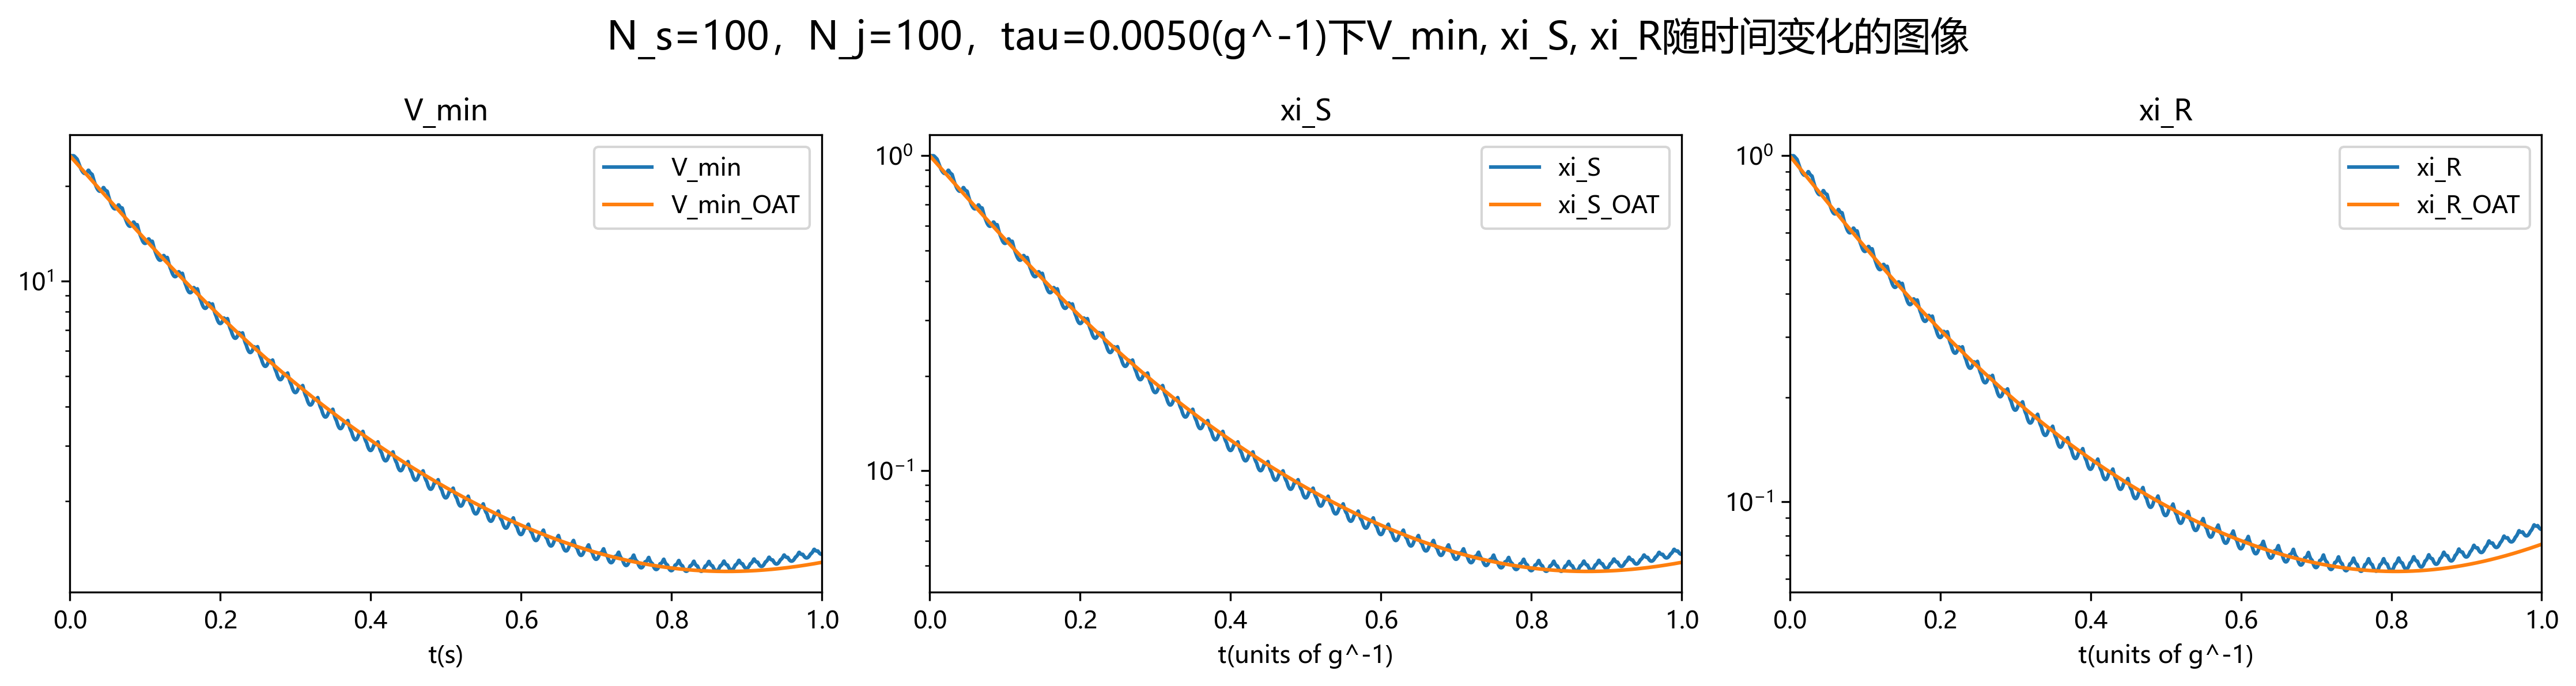

In [119]:
fig, ax = plt.subplots(1, 3, figsize=(15,4), dpi=300)
fig.suptitle(f'N_s={N_s}，N_j={N_j}，tau={tau:.4f}(g^-1)下V_min, xi_S, xi_R随时间变化的图像', fontsize=16)
ax[0].plot(t_list, V_min, label='V_min')
ax[0].plot(t_list, V_min_OAT, label='V_min_OAT')
ax[0].set_title("V_min")
ax[0].set_xlabel("t(s)")
ax[0].set_xlim(0, 1)
ax[0].set_yscale('log')
ax[0].legend()

ax[1].plot(t_list, V_min/(j_s/2), label='xi_S')
ax[1].plot(t_list, V_min_OAT/(j_s/2), label='xi_S_OAT')
ax[1].set_title("xi_S")
ax[1].set_xlabel("t(units of g^-1)")
ax[1].set_xlim(0, 1)
ax[1].set_yscale('log')
ax[1].legend()

ax[2].plot(t_list, V_min*j_s / (exp_J**2 / 2), label='xi_R')
ax[2].plot(t_list, V_min_OAT*j_s / (R2_OAT / 2), label='xi_R_OAT')
ax[2].set_title("xi_R")
ax[2].set_xlabel("t(units of g^-1)")
ax[2].legend()
ax[2].set_xlim(0, 1)
ax[2].set_yscale('log')


fig.tight_layout()
plt.show() 

#### 不同脉冲周期$\tau$对压缩性能的影响

In [128]:
def V_min_given_tau_or_periods(tau=None, Periods=None, t_max=1.4, t_num_scale=10, N_j=50, N_s=100, g=1, get_t_min_and_V_min_min=False, compare_with_OAT=False):
    """
    输入参数：
    tau: 脉冲周期
    Periods: 脉冲周期对应的总周期数
    t_max: 最大时间
    t_num_scale: 时间点数量的比例
    N_j: 系统参数
    N_s: 系统参数
    g: 系统参数
    get_t_min_and_V_min_min: 是否返回最小值及其对应的时间点
    compare_with_OAT: 是否与OAT结果进行比较
    """
    
    if tau is not None:
        periods = int(t_max / tau)
    elif Periods is not None:
        periods = Periods
        tau = t_max / periods
    else:
        raise ValueError("必须提供tau或Periods中的一个参数")
    print(f"tau={tau:.4f}，N_j={N_j}，N_s={N_s}")
    N_j = N_j
    N_s = N_s
    j_j = N_j / 2
    j_s = N_s / 2
    psi_0_j = custom_spin_coherent(j_j, np.pi / 2, 0)
    psi_0_s = custom_spin_coherent(j_s, np.pi / 2, 0)
    psi_0 = tensor(psi_0_j, psi_0_s)
    J_z = tensor(jmat(j_j, 'z'), qeye(N_s + 1))
    S_z = tensor(qeye(N_j + 1), jmat(j_s, 'z'))
    J_x = tensor(jmat(j_j, 'x'), qeye(N_s + 1))
    S_x = tensor(qeye(N_j + 1), jmat(j_s, 'x'))
    J_y = tensor(jmat(j_j, 'y'), qeye(N_s + 1))
    S_y = tensor(qeye(N_j + 1), jmat(j_s, 'y'))
    
    t_num = t_num_scale * periods
    t_min_interval = t_max / t_num
    t_list = np.linspace(0, t_max, t_num)
    scale = 1
    delta_t = t_min_interval * scale
    Omega = np.pi / (2 * delta_t)
    def f_1(t, args):
        t_mod = t % tau
        if t_mod >= tau - delta_t - 1e-10 or t_mod < 1e-10:
            return Omega
        else:
            return 0
    H = [g * S_z * J_z, [J_x, f_1]]
    result = mesolve(H, psi_0, t_list, c_ops=[], e_ops=[S_x, S_y, S_z, S_x*S_x, S_y*S_y, S_z*S_z, S_x*S_y+S_y*S_x, S_y*S_z+S_z*S_y, S_z*S_x+S_x*S_z],
                options={"store_states": True,
                         "nsteps": 10000,
                         "atol": 1e-9,
                         "rtol": 1e-9,
                         "max_step": t_min_interval})
    Sx_exp, Sy_exp, Sz_exp, Sx2_exp, Sy2_exp, Sz2_exp, Sxy_exp, Syz_exp, Szx_exp = result.expect
    exp_Sx = Sx_exp
    exp_Sy = Sy_exp
    exp_Sz = Sz_exp
    Cov_xx = Sx2_exp - Sx_exp * Sx_exp
    Cov_yy = Sy2_exp - Sy_exp * Sy_exp
    Cov_zz = Sz2_exp - Sz_exp * Sz_exp
    Cov_xy = 1/2 * Sxy_exp - Sx_exp * Sy_exp
    Cov_yz = 1/2 * Syz_exp - Sy_exp * Sz_exp
    Cov_zx = 1/2 * Szx_exp - Sz_exp * Sx_exp
    exp_J = np.sqrt(Sx_exp**2 + Sy_exp**2 + Sz_exp**2)
    V_min = calculate_Vmin_dynamics(exp_Sx, exp_Sy, exp_Sz, Cov_xx, Cov_yy, Cov_zz, Cov_xy, Cov_yz, Cov_zx)
    if get_t_min_and_V_min_min and compare_with_OAT:
        V_min_min = np.min(V_min)
        t_min = t_list[np.argmin(V_min)]
        s_z = jmat(j_s, 'z')
        s_x = jmat(j_s, 'x')
        s_y = jmat(j_s, 'y')
        chi = g**2 * N_j * tau / 8
        H = chi * s_z * s_z
        result_OAT = mesolve(H, psi_0_s, t_list, c_ops=[], e_ops=[s_x, s_y, s_z, s_x*s_x, s_y*s_y, s_z*s_z, s_x*s_y+s_y*s_x, s_y*s_z+s_z*s_y, s_z*s_x+s_x*s_z], options={"store_states": True})
        Sx_exp_OAT, Sy_exp_OAT, Sz_exp_OAT, Sx2_exp_OAT, Sy2_exp_OAT, Sz2_exp_OAT, Sxy_exp_OAT, Syz_exp_OAT, Szx_exp_OAT = result_OAT.expect
        exp_Sx_OAT = Sx_exp_OAT
        Cov_xx_OAT = Sx2_exp_OAT - Sx_exp_OAT * Sx_exp_OAT
        Cov_yy_OAT = Sy2_exp_OAT - Sy_exp_OAT * Sy_exp_OAT
        Cov_zz_OAT = Sz2_exp_OAT - Sz_exp_OAT * Sz_exp_OAT
        Cov_xy_OAT = 1/2 * Sxy_exp_OAT - Sx_exp_OAT * Sy_exp_OAT
        Cov_yz_OAT = 1/2 * Syz_exp_OAT - Sy_exp_OAT * Sz_exp_OAT
        Cov_zx_OAT = 1/2 * Szx_exp_OAT - Sz_exp_OAT * Sx_exp_OAT
        V_min_OAT = calculate_Vmin_dynamics(exp_Sx_OAT, Sy_exp_OAT, Sz_exp_OAT, Cov_xx_OAT, Cov_yy_OAT, Cov_zz_OAT, Cov_xy_OAT, Cov_yz_OAT, Cov_zx_OAT)
        V_min_min_OAT = np.min(V_min_OAT)
        t_min_OAT = t_list[np.argmin(V_min_OAT)]
        return t_list, V_min, t_min, V_min_min, t_min_OAT, V_min_min_OAT
    elif get_t_min_and_V_min_min:
        V_min_min = np.min(V_min)
        t_min = t_list[np.argmin(V_min)]
        return t_list, V_min, t_min, V_min_min
    elif compare_with_OAT:
        s_z = jmat(j_s, 'z')
        s_x = jmat(j_s, 'x')
        s_y = jmat(j_s, 'y')
        chi = g**2 * N_j * tau / 8
        H = chi * s_z * s_z
        result_OAT = mesolve(H, psi_0_s, t_list, c_ops=[], e_ops=[s_x, s_y, s_z, s_x*s_x, s_y*s_y, s_z*s_z, s_x*s_y+s_y*s_x, s_y*s_z+s_z*s_y, s_z*s_x+s_x*s_z], options={"store_states": True})
        Sx_exp_OAT, Sy_exp_OAT, Sz_exp_OAT, Sx2_exp_OAT, Sy2_exp_OAT, Sz2_exp_OAT, Sxy_exp_OAT, Syz_exp_OAT, Szx_exp_OAT = result_OAT.expect
        exp_Sx_OAT = Sx_exp_OAT
        Cov_xx_OAT = Sx2_exp_OAT - Sx_exp_OAT * Sx_exp_OAT
        Cov_yy_OAT = Sy2_exp_OAT - Sy_exp_OAT * Sy_exp_OAT
        Cov_zz_OAT = Sz2_exp_OAT - Sz_exp_OAT * Sz_exp_OAT
        Cov_xy_OAT = 1/2 * Sxy_exp_OAT - Sx_exp_OAT * Sy_exp_OAT
        Cov_yz_OAT = 1/2 * Syz_exp_OAT - Sy_exp_OAT * Sz_exp_OAT
        Cov_zx_OAT = 1/2 * Szx_exp_OAT - Sz_exp_OAT * Sx_exp_OAT
        V_min_OAT = calculate_Vmin_dynamics(exp_Sx_OAT, Sy_exp_OAT, Sz_exp_OAT, Cov_xx_OAT, Cov_yy_OAT, Cov_zz_OAT, Cov_xy_OAT, Cov_yz_OAT, Cov_zx_OAT)
        return t_list, V_min, V_min_OAT
    else:
        return t_list, V_min

In [124]:
t_list_0006, V_min_0006, V_min_OAT_0006 = V_min_given_tau_or_periods(tau=0.006, compare_with_OAT=True)
t_list_0013, V_min_0013, V_min_OAT_0013 = V_min_given_tau_or_periods(tau=0.013, compare_with_OAT=True)
t_list_0030, V_min_0030, V_min_OAT_0030 = V_min_given_tau_or_periods(tau=0.030, compare_with_OAT=True)
t_list_0042, V_min_0042, V_min_OAT_0042 = V_min_given_tau_or_periods(tau=0.042, compare_with_OAT=True)


tau=0.0060，N_j=50，N_s=100
tau=0.0130，N_j=50，N_s=100
tau=0.0300，N_j=50，N_s=100
tau=0.0420，N_j=50，N_s=100


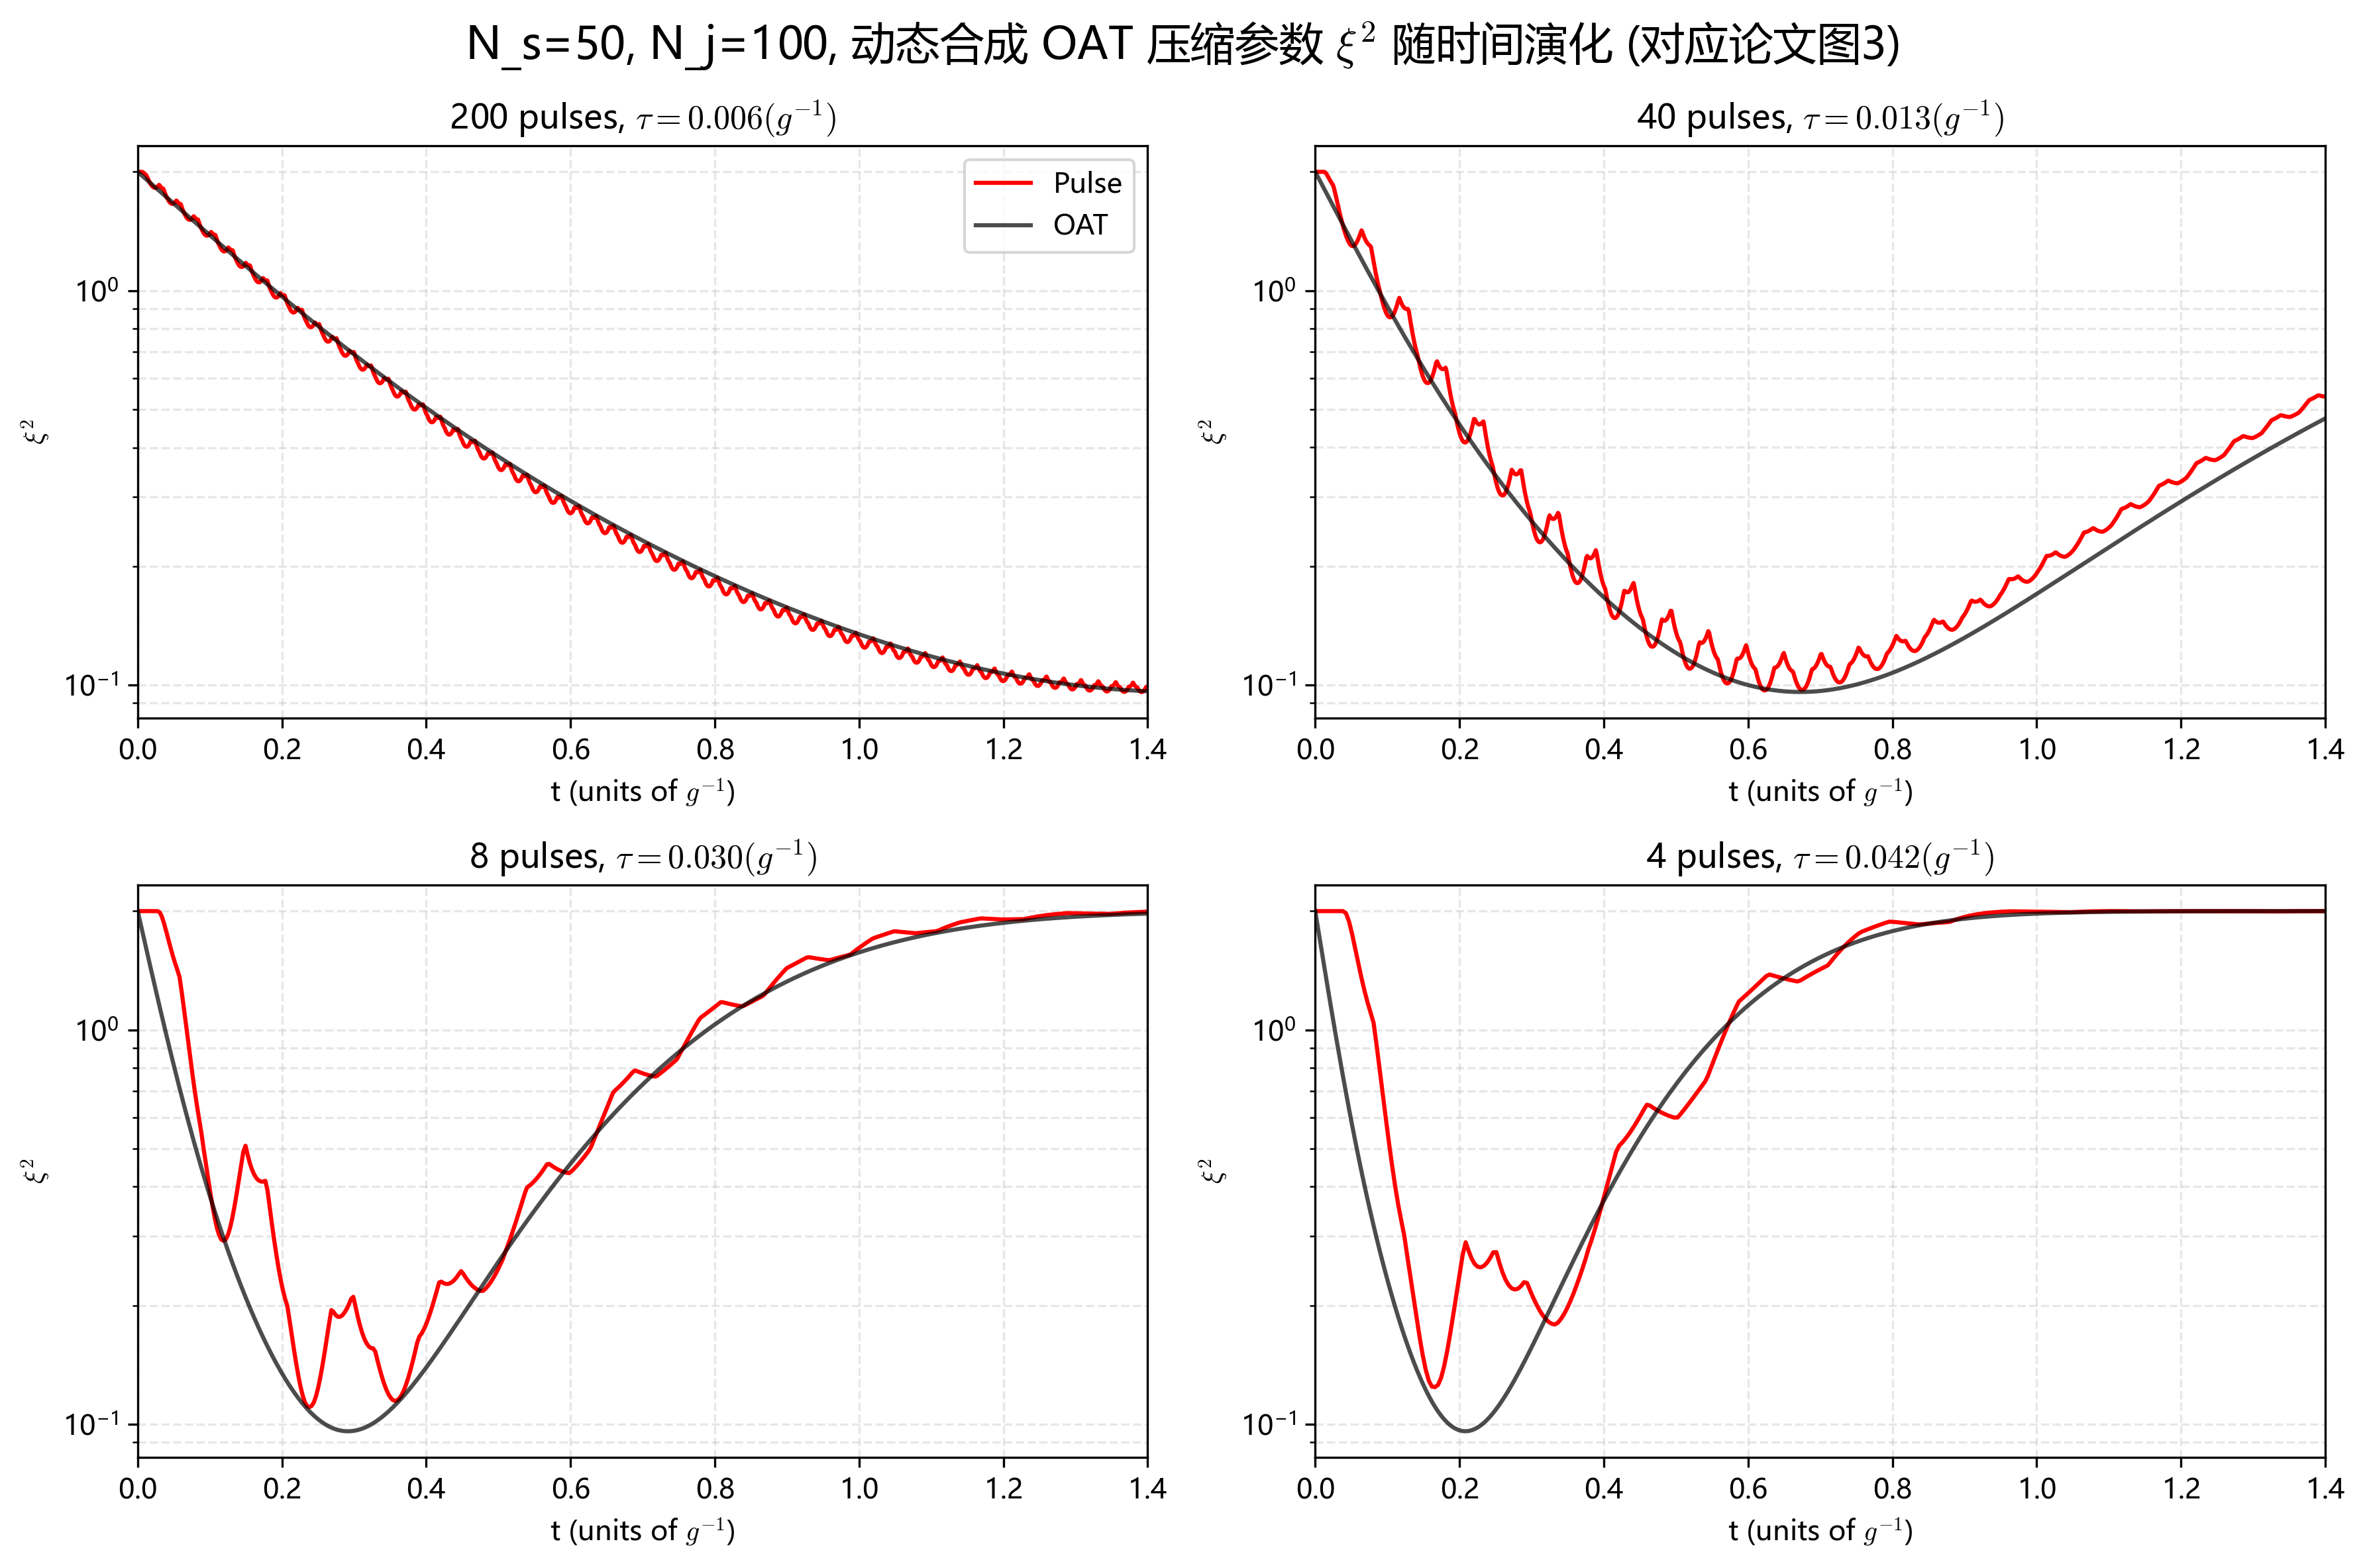

In [137]:
fig, ax = plt.subplots(2, 2, figsize=(12,8), dpi=300)
fig.suptitle(f'N_s={N_s}, N_j={N_j}, 动态合成 OAT 压缩参数 $\\xi^2$ 随时间演化 (对应论文图3)', fontsize=16)

# 转化为 xi^2 参数: 4 * V_min / N_s
xi2_0006, xi2_OAT_0006 = 4 * V_min_0006 / N_s, 4 * V_min_OAT_0006 / N_s
xi2_0013, xi2_OAT_0013 = 4 * V_min_0013 / N_s, 4 * V_min_OAT_0013 / N_s
xi2_0030, xi2_OAT_0030 = 4 * V_min_0030 / N_s, 4 * V_min_OAT_0030 / N_s
xi2_0042, xi2_OAT_0042 = 4 * V_min_0042 / N_s, 4 * V_min_OAT_0042 / N_s

# 绘制图 3(a) 对应 200 pulses
ax[0, 0].plot(t_list_0006, xi2_0006, 'r-', label='Pulse')
ax[0, 0].plot(t_list_0006, xi2_OAT_0006, 'k-', alpha=0.7, label='OAT')
ax[0, 0].set_title("200 pulses, $\\tau=0.006 (g^{-1})$")
ax[0, 0].set_yscale('log')
ax[0, 0].set_xlim(0, 1.4)
ax[0, 0].legend()

# 绘制图 3(b) 对应 40 pulses
ax[0, 1].plot(t_list_0013, xi2_0013, 'r-', label='Pulse')
ax[0, 1].plot(t_list_0013, xi2_OAT_0013, 'k-', alpha=0.7, label='OAT')
ax[0, 1].set_title("40 pulses, $\\tau=0.013 (g^{-1})$")
ax[0, 1].set_yscale('log')
ax[0, 1].set_xlim(0, 1.4)

# 绘制图 3(c) 对应 8 pulses
ax[1, 0].plot(t_list_0030, xi2_0030, 'r-', label='Pulse')
ax[1, 0].plot(t_list_0030, xi2_OAT_0030, 'k-', alpha=0.7, label='OAT')
ax[1, 0].set_title("8 pulses, $\\tau=0.030 (g^{-1})$")
ax[1, 0].set_yscale('log')
ax[1, 0].set_xlim(0, 1.4)

# 绘制图 3(d) 对应 4 pulses
ax[1, 1].plot(t_list_0042, xi2_0042, 'r-', label='Pulse')
ax[1, 1].plot(t_list_0042, xi2_OAT_0042, 'k-', alpha=0.7, label='OAT')
ax[1, 1].set_title("4 pulses, $\\tau=0.042 (g^{-1})$")
ax[1, 1].set_yscale('log')
ax[1, 1].set_xlim(0, 1.4)

for axis in ax.flat:
    axis.set_xlabel("t (units of $g^{-1}$)")
    axis.set_ylabel("$\\xi^2$")
    axis.grid(True, which="both", ls="--", alpha=0.3)

fig.tight_layout()
plt.show()

绘制$\xi^2_{min}$和$t_{min}$随Pulse number的变化曲线

In [130]:
def custom_spin_coherent(j, theta, phi):
    N = int(2 * j)
    i = np.arange(N + 1)
    p = np.sin(theta / 2)**2
    prob_m = binom.pmf(i, N, p)
    return Qobj(np.sqrt(prob_m) * np.exp(1j * i * phi)).unit()

def calculate_Vmin_dynamics(exp_Jx, exp_Jy, exp_Jz, Cov_xx, Cov_yy, Cov_zz, Cov_xy, Cov_yz, Cov_zx):
    T = len(exp_Jx)
    R = np.sqrt(exp_Jx**2 + exp_Jy**2 + exp_Jz**2)
    n0 = np.zeros((T, 3, 1))
    n0[:, 0, 0], n0[:, 1, 0], n0[:, 2, 0] = exp_Jx / R, exp_Jy / R, exp_Jz / R
    I = np.eye(3).reshape(1, 3, 3)
    P = I - np.matmul(n0, np.transpose(n0, axes=(0, 2, 1)))
    Sigma = np.zeros((T, 3, 3))
    Sigma[:, 0, 0], Sigma[:, 1, 1], Sigma[:, 2, 2] = Cov_xx, Cov_yy, Cov_zz
    Sigma[:, 0, 1] = Sigma[:, 1, 0] = Cov_xy
    Sigma[:, 1, 2] = Sigma[:, 2, 1] = Cov_yz
    Sigma[:, 0, 2] = Sigma[:, 2, 0] = Cov_zx
    Sigma_tilde = np.matmul(P, np.matmul(Sigma, P))
    tr_Sigma = np.trace(Sigma_tilde, axis1=1, axis2=2)
    tr_Sigma_sq = np.trace(np.matmul(Sigma_tilde, Sigma_tilde), axis1=1, axis2=2)
    return 0.5 * (tr_Sigma - np.sqrt(np.abs(2 * tr_Sigma_sq - tr_Sigma**2)))

def V_min_given_tau_exact(tau, t_max, N_j=50, N_s=100, g=1):
    j_j, j_s = N_j / 2, N_s / 2
    psi_0 = tensor(custom_spin_coherent(j_j, np.pi / 2, 0), custom_spin_coherent(j_s, np.pi / 2, 0))
    
    J_z = tensor(jmat(j_j, 'z'), qeye(N_s + 1))
    S_z = tensor(qeye(N_j + 1), jmat(j_s, 'z'))
    J_x = tensor(jmat(j_j, 'x'), qeye(N_s + 1))
    S_x = tensor(qeye(N_j + 1), jmat(j_s, 'x'))
    S_y = tensor(qeye(N_j + 1), jmat(j_s, 'y'))
    
    delta_t = tau / 100.0
    Omega = np.pi / (2 * delta_t)
    
    # 根据 t_max 动态分配时间点，确保脉冲和波谷都能被捕捉
    t_num = int(t_max / delta_t) * 2 
    t_list = np.linspace(0, t_max, t_num)
    
    def f_1(t, args):
        t_mod = t % tau
        if t_mod > tau - delta_t:
            return Omega
        return 0.0

    H = [g * S_z * J_z, [J_x, f_1]]
    result = mesolve(H, psi_0, t_list, c_ops=[], 
                     e_ops=[S_x, S_y, S_z, S_x*S_x, S_y*S_y, S_z*S_z, S_x*S_y+S_y*S_x, S_y*S_z+S_z*S_y, S_z*S_x+S_x*S_z],
                     options={"store_states": False, "nsteps": 20000, "max_step": delta_t / 2.0})
    
    Sx, Sy, Sz, Sx2, Sy2, Sz2, Sxy, Syz, Szx = result.expect
    V_min = calculate_Vmin_dynamics(Sx, Sy, Sz, Sx2-Sx**2, Sy2-Sy**2, Sz2-Sz**2, 
                                    0.5*Sxy-Sx*Sy, 0.5*Syz-Sy*Sz, 0.5*Szx-Sz*Sx)
    
    # 计算理论 OAT 对比
    s_z, s_x, s_y = jmat(j_s, 'z'), jmat(j_s, 'x'), jmat(j_s, 'y')
    H_OAT = (g**2 * N_j * tau / 8) * s_z * s_z
    res_OAT = mesolve(H_OAT, custom_spin_coherent(j_s, np.pi/2, 0), t_list, c_ops=[], 
                      e_ops=[s_x, s_y, s_z, s_x*s_x, s_y*s_y, s_z*s_z, s_x*s_y+s_y*s_x, s_y*s_z+s_z*s_y, s_z*s_x+s_x*s_z], 
                      options={"store_states": False})
    SxO, SyO, SzO, Sx2O, Sy2O, Sz2O, SxyO, SyzO, SzxO = res_OAT.expect
    V_min_OAT = calculate_Vmin_dynamics(SxO, SyO, SzO, Sx2O-SxO**2, Sy2O-SyO**2, Sz2O-SzO**2, 
                                        0.5*SxyO-SxO*SyO, 0.5*SyzO-SyO*SzO, 0.5*SzxO-SzO*SxO)
    
    return t_list, V_min, V_min_OAT

In [131]:
N_s = 50
N_j = 100
g = 1
pulse_list = np.array([4, 10, 20, 40, 60, 80, 100, 120, 160, 200], dtype=int) 

V_min_results, V_min_OAT_results = [], []
t_min_results, t_min_OAT_results = [], []

for pulse in pulse_list:
    constant = 8 * (3**(1/6))
    tau = np.sqrt(constant / (pulse * (g**2) * N_j * (N_s**(2/3))))
    t_max = 1.3 * pulse * tau 
    print(f"正在模拟 Pulse: {pulse}, 自动推导 tau: {tau:.4f}, t_max: {t_max:.4f}")
    t_list, V_min, V_min_OAT = V_min_given_tau_exact(tau, t_max, N_j=N_j, N_s=N_s, g=g)

    idx_min = np.argmin(V_min)
    idx_min_OAT = np.argmin(V_min_OAT)
    
    V_min_results.append(V_min[idx_min])
    t_min_results.append(t_list[idx_min])
    V_min_OAT_results.append(V_min_OAT[idx_min_OAT])
    t_min_OAT_results.append(t_list[idx_min_OAT])


正在模拟 Pulse: 4, 自动推导 tau: 0.0421, t_max: 0.2188
正在模拟 Pulse: 10, 自动推导 tau: 0.0266, t_max: 0.3459
正在模拟 Pulse: 20, 自动推导 tau: 0.0188, t_max: 0.4891
正在模拟 Pulse: 40, 自动推导 tau: 0.0133, t_max: 0.6918
正在模拟 Pulse: 60, 自动推导 tau: 0.0109, t_max: 0.8472
正在模拟 Pulse: 80, 自动推导 tau: 0.0094, t_max: 0.9783
正在模拟 Pulse: 100, 自动推导 tau: 0.0084, t_max: 1.0938
正在模拟 Pulse: 120, 自动推导 tau: 0.0077, t_max: 1.1982
正在模拟 Pulse: 160, 自动推导 tau: 0.0067, t_max: 1.3835
正在模拟 Pulse: 200, 自动推导 tau: 0.0059, t_max: 1.5468


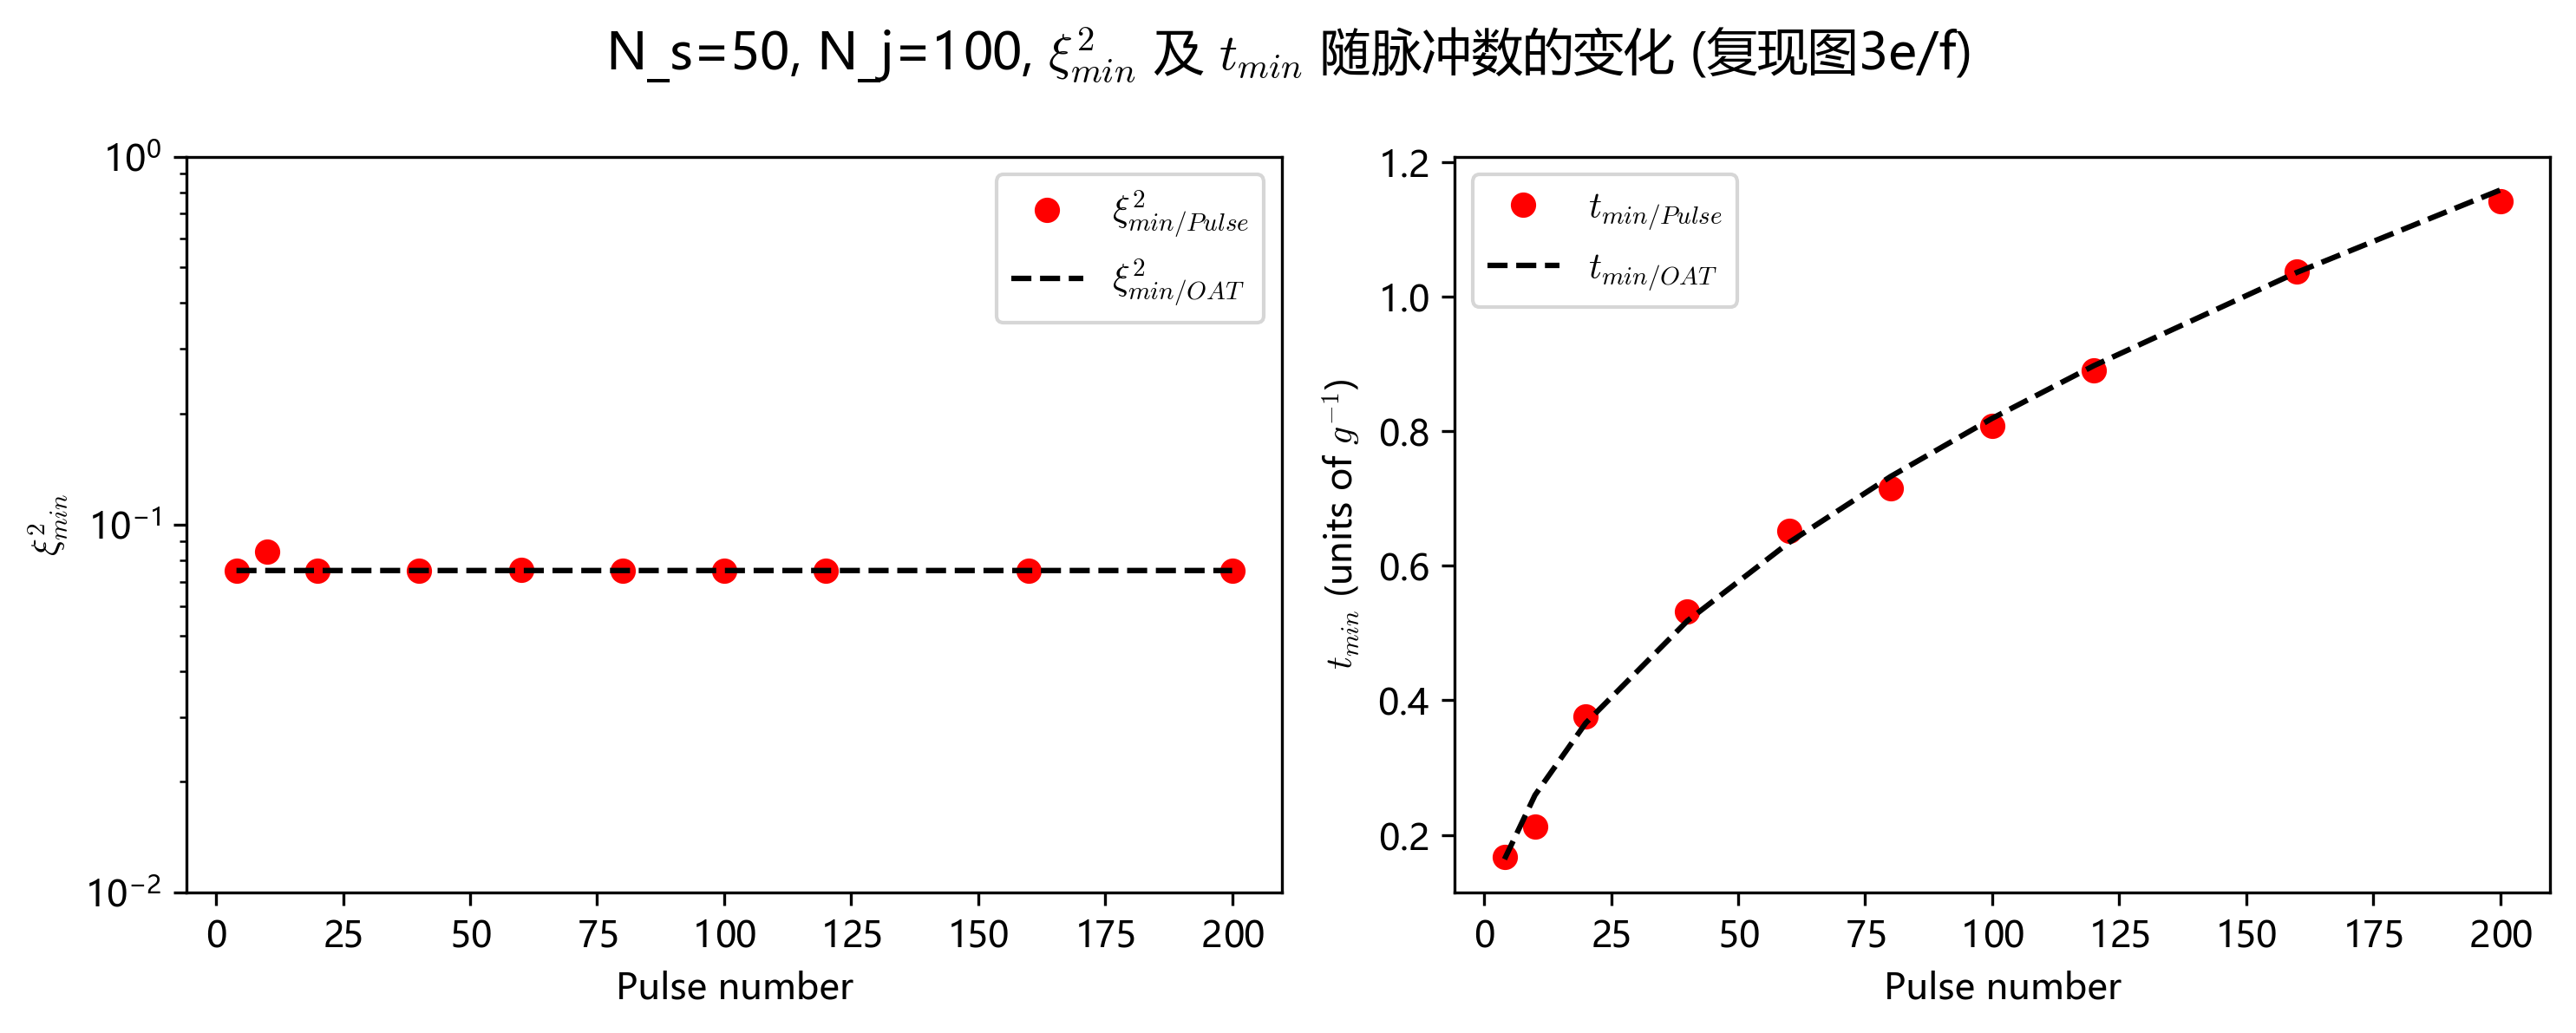

In [136]:

fig, ax1 = plt.subplots(1, 2, figsize=(10,4), dpi=300)
fig.suptitle(f'N_s={N_s}, N_j={N_j}, $\\xi^2_{{min}}$ 及 $t_{{min}}$ 随脉冲数的变化 (复现图3e/f)', fontsize=14)
xi2_min_results = 4 * np.array(V_min_results) / N_s
xi2_min_OAT_results = 4 * np.array(V_min_OAT_results) / N_s

ax1[0].plot(pulse_list, xi2_min_results, 'ro', label='$\\xi_{min/Pulse}^2$')
ax1[0].plot(pulse_list, xi2_min_OAT_results, 'k--', label='$\\xi_{min/OAT}^2$')
ax1[0].set_xlabel("Pulse number")
ax1[0].set_ylabel("$\\xi^2_{min}$")
ax1[0].set_ylim(1e-2, 1)
ax1[0].set_yscale('log')
ax1[0].legend()

ax1[1].plot(pulse_list, t_min_results, 'ro', label='$t_{min/Pulse}$')
ax1[1].plot(pulse_list, t_min_OAT_results, 'k--', label='$t_{min/OAT}$')
ax1[1].set_xlabel("Pulse number")
ax1[1].set_ylabel("$t_{min}$ (units of $g^{-1}$)")
ax1[1].legend()

fig.tight_layout()
plt.show()

绘制$\xi^2_{min}$和$t_{min}$随$N_s$的变化曲线

由于粒子数很大，我们在一个单独的python文件中进行了大粒子数的优化计算，结果如下：
<div style="display: flex; justify-content: center; align-items: center; gap: 20px;">
    <div style="text-align: center;">
        <img src="Figure\合成OAT_ximintmin_with_N_s.png" width="1000" height="400" />
        <p><b>脉冲合成OAT与OAT的对比，Eq.(10)为公式(10)的理论计算结果</b></p>
    </div>
</div>

$$
\begin{equation*}
\xi^2_{min} \simeq \frac{1}{2}(\frac{N_s}{3})^{-\frac{2}{3}} \quad,
t_{min} \simeq \frac{8 \times 3^{1/6}}{g^2 \tau N_j N_s^{2/3}} \qquad (10)
\end{equation*}
$$

### 合成TAT模型

In [ ]:
def custom_spin_coherent(j, theta, phi):
    N = int(2 * j)
    i = np.arange(N + 1)
    p = np.sin(theta / 2)**2
    prob_m = binom.pmf(i, N, p)
    amp = np.sqrt(prob_m)
    phase = np.exp(1j * i * phi)
    return Qobj(amp * phase).unit()

def calculate_Vmin_dynamics(exp_Jx, exp_Jy, exp_Jz, Cov_xx, Cov_yy, Cov_zz, Cov_xy, Cov_yz, Cov_zx):
    T = len(exp_Jx)
    R = np.sqrt(exp_Jx**2 + exp_Jy**2 + exp_Jz**2)
    R_safe = np.where(R == 0, 1e-12, R)
    n0 = np.zeros((T, 3, 1))
    n0[:, 0, 0], n0[:, 1, 0], n0[:, 2, 0] = exp_Jx / R_safe, exp_Jy / R_safe, exp_Jz / R_safe
    I = np.eye(3).reshape(1, 3, 3)
    P = I - np.matmul(n0, np.transpose(n0, axes=(0, 2, 1)))
    Sigma = np.zeros((T, 3, 3))
    Sigma[:, 0, 0], Sigma[:, 1, 1], Sigma[:, 2, 2] = Cov_xx, Cov_yy, Cov_zz
    Sigma[:, 0, 1] = Sigma[:, 1, 0] = Cov_xy
    Sigma[:, 1, 2] = Sigma[:, 2, 1] = Cov_yz
    Sigma[:, 0, 2] = Sigma[:, 2, 0] = Cov_zx
    Sigma_tilde = np.matmul(P, np.matmul(Sigma, P))
    tr_Sigma = np.trace(Sigma_tilde, axis1=1, axis2=2)
    tr_Sigma_sq = np.trace(np.matmul(Sigma_tilde, Sigma_tilde), axis1=1, axis2=2)
    return 0.5 * (tr_Sigma - np.sqrt(np.abs(2 * tr_Sigma_sq - tr_Sigma**2)))

def V_min_given_tau_or_periods_TAT(tau, t_max=None, N_j=10, N_s=10, g=1):
    print(f"TAT 模拟开始: tau={tau:.4f}，N_j={N_j}，N_s={N_s}")
    j_j, j_s = N_j / 2.0, N_s / 2.0
    
    if t_max is None:
        t_min_est = (8 * np.log(4 * N_s)) / (g**2 * tau * N_j * N_s)
        t_max = t_min_est * 1.2
        print(f"已根据理论估算设置 t_max = {t_max:.2f}")

    psi_0 = tensor(custom_spin_coherent(j_j, np.pi / 2, 0), custom_spin_coherent(j_s, np.pi / 2, 0))
    
    J_z = tensor(jmat(j_j, 'z'), qeye(int(N_s + 1)))
    S_z = tensor(qeye(int(N_j + 1)), jmat(j_s, 'z'))
    J_x = tensor(jmat(j_j, 'x'), qeye(int(N_s + 1)))
    S_x = tensor(qeye(int(N_j + 1)), jmat(j_s, 'x'))
    S_y = tensor(qeye(int(N_j + 1)), jmat(j_s, 'y'))
    
    delta_t = tau / 20.0
    Omega = np.pi / (2 * delta_t)
    t_num = int(t_max / delta_t) * 2
    t_list = np.linspace(0, t_max, t_num)
    
    pulse_J = np.zeros_like(t_list)
    pulse_S = np.zeros_like(t_list)
    
    for i, t in enumerate(t_list):
        phase = (t / tau) % 8.0
        if phase < 1e-5 and t > 1e-5:
            phase = 8.0
            
        window = delta_t / tau
        for k in range(1, 9):
            if (k - window - 1e-7) <= phase <= (k + 1e-7):
                pulse_J[i] = Omega if k <= 4 else -Omega
                if k == 4:
                    pulse_S[i] = -Omega
                elif k == 8:
                    pulse_S[i] = Omega

    H = [g * S_z * J_z, [J_x, pulse_J], [S_x, pulse_S]]
    
    e_ops = [S_x, S_y, S_z, S_x*S_x, S_y*S_y, S_z*S_z, S_x*S_y+S_y*S_x, S_y*S_z+S_z*S_y, S_z*S_x+S_x*S_z]
    opts = Options(store_states=False, nsteps=30000, max_step=delta_t/2.0)
    result = sesolve(H, psi_0, t_list, e_ops=e_ops, options=opts)
    
    Sx, Sy, Sz, Sx2, Sy2, Sz2, Sxy, Syz, Szx = result.expect
    V_min = calculate_Vmin_dynamics(Sx, Sy, Sz, Sx2-Sx**2, Sy2-Sy**2, Sz2-Sz**2, 
                                    0.5*Sxy-Sx*Sy, 0.5*Syz-Sy*Sz, 0.5*Szx-Sz*Sx)
    
    # ================= 纯理论 TAT 对比组 =================
    s_z, s_x, s_y = jmat(j_s, 'z'), jmat(j_s, 'x'), jmat(j_s, 'y')
    chi_TAT = (g**2 * N_j * tau) / 16.0
    H_TAT = chi_TAT * (s_z * s_z - s_y * s_y)
    
    res_TAT = sesolve(H_TAT, custom_spin_coherent(j_s, np.pi / 2, 0), t_list, e_ops=[s_x, s_y, s_z, s_x*s_x, s_y*s_y, s_z*s_z, s_x*s_y+s_y*s_x, s_y*s_z+s_z*s_y, s_z*s_x+s_x*s_z], options=Options(store_states=False))
    SxO, SyO, SzO, Sx2O, Sy2O, Sz2O, SxyO, SyzO, SzxO = res_TAT.expect
    V_min_TAT = calculate_Vmin_dynamics(SxO, SyO, SzO, Sx2O-SxO**2, Sy2O-SyO**2, Sz2O-SzO**2, 0.5*SxyO-SxO*SyO, 0.5*SyzO-SyO*SzO, 0.5*SzxO-SzO*SxO)
    
    return t_list, V_min, V_min_TAT

TAT 模拟开始: tau=0.0100，N_j=40，N_s=20
已根据理论估算设置 t_max = 5.26


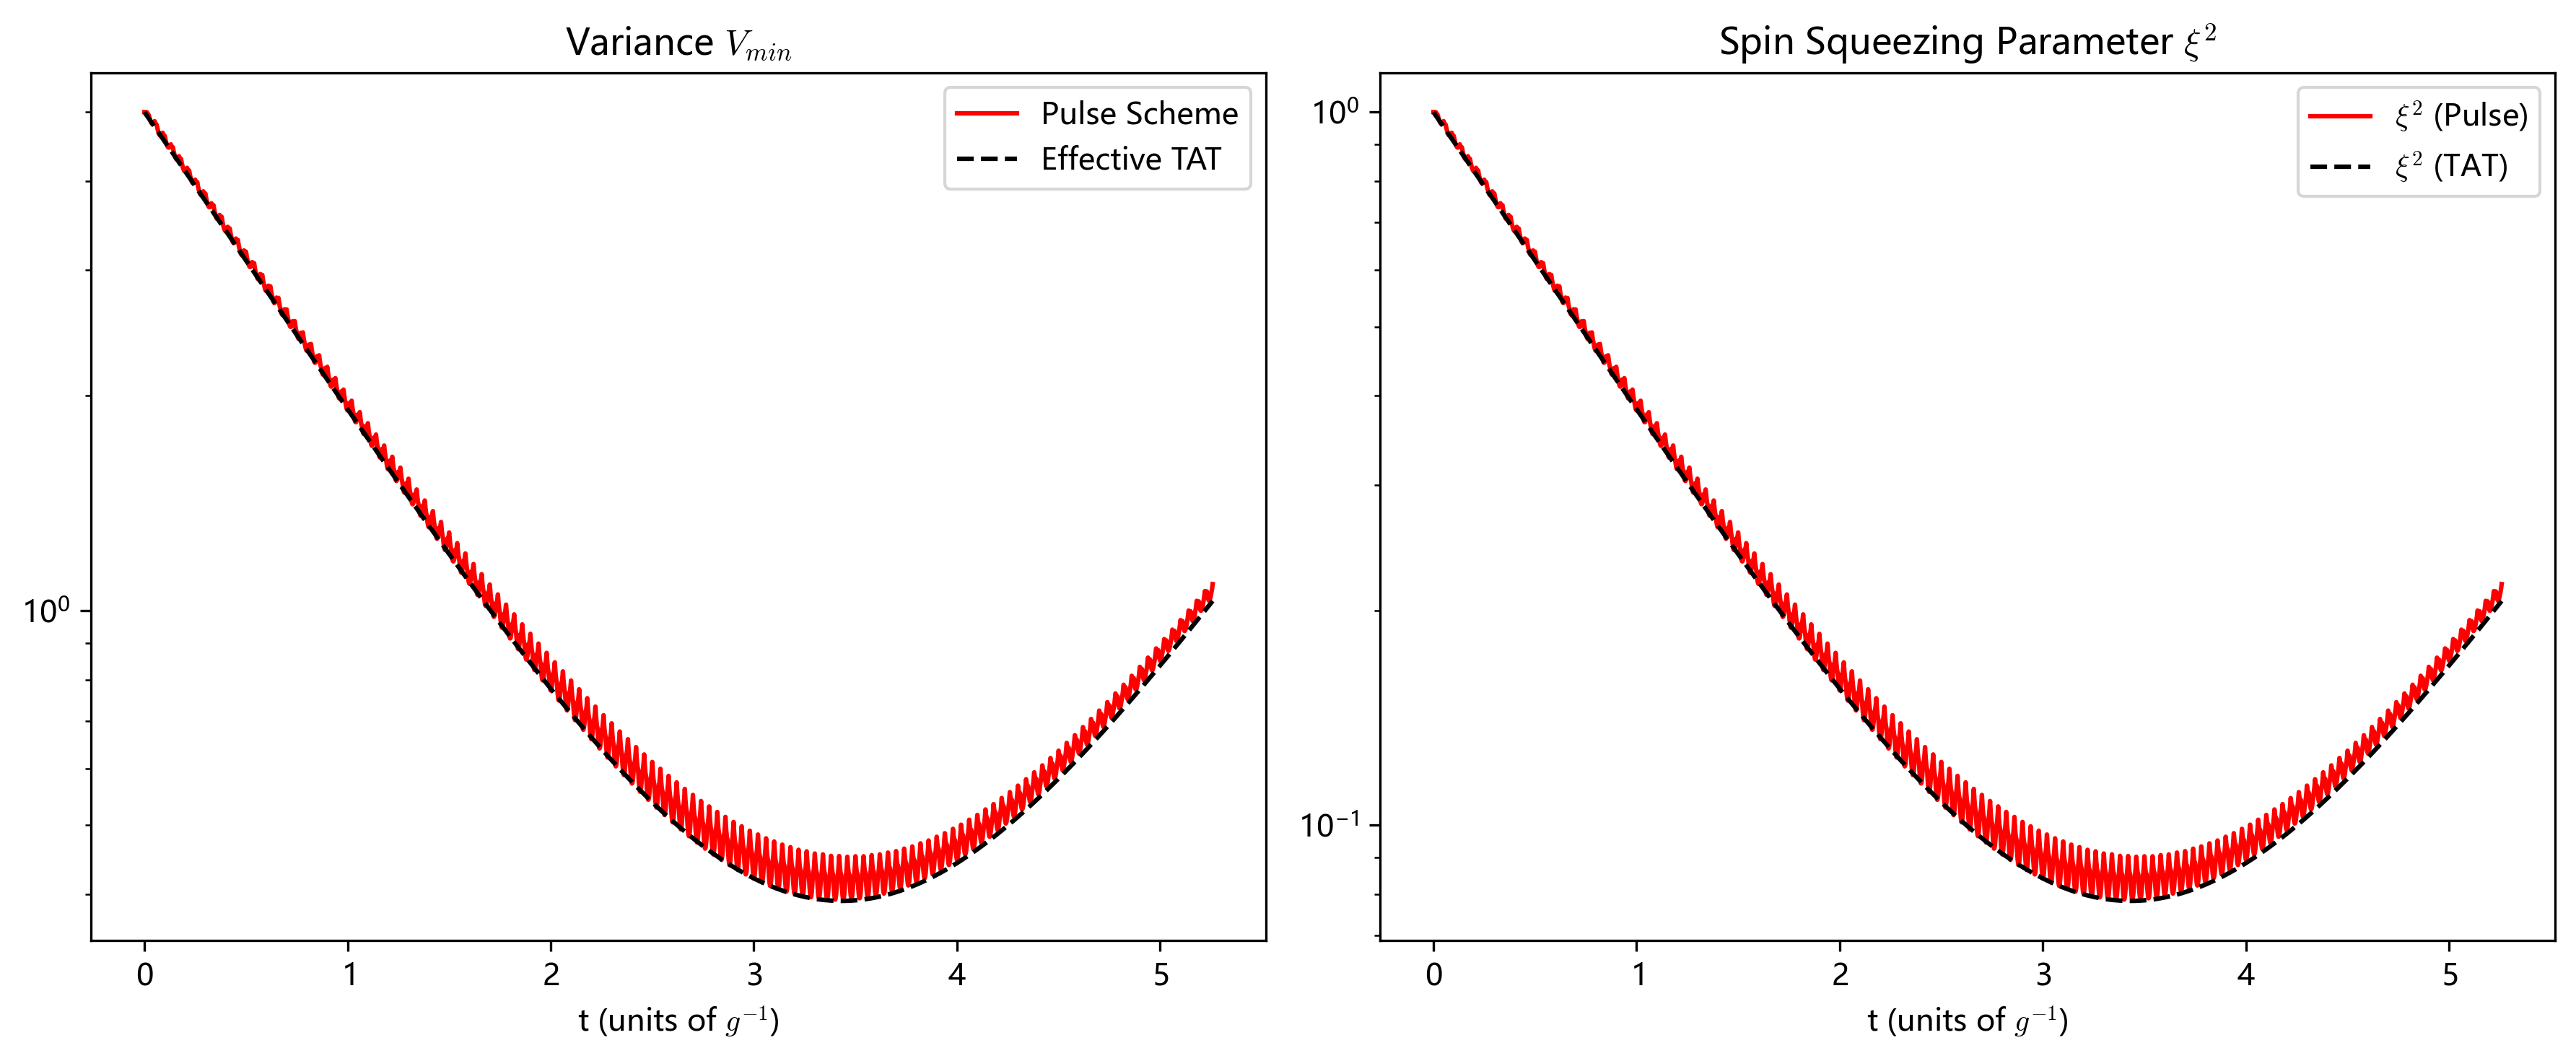

In [151]:
N_s = 20
N_j = 40
tau = 0.005
t_list, V_min, V_min_TAT = V_min_given_tau_or_periods_TAT(tau=tau, t_max=None, N_j=N_j, N_s=N_s, g=1)

fig, ax = plt.subplots(1, 2, figsize=(12,5), dpi=300)
xi_2 = 4 * V_min / N_s
xi_2_TAT = 4 * V_min_TAT / N_s

ax[0].plot(t_list, V_min, 'r-', label='Pulse Scheme')
ax[0].plot(t_list, V_min_TAT, 'k--', label='Effective TAT')
ax[0].set_title(r"Variance $V_{min}$")
ax[0].set_xlabel(r"t (units of $g^{-1}$)")
ax[0].set_yscale('log')
ax[0].legend()

ax[1].plot(t_list, xi_2, 'r-', label=r'$\xi^2$ (Pulse)')
ax[1].plot(t_list, xi_2_TAT, 'k--', label=r'$\xi^2$ (TAT)')
ax[1].set_title(r"Spin Squeezing Parameter $\xi^2$")
ax[1].set_xlabel(r"t (units of $g^{-1}$)")
ax[1].set_yscale('log')
ax[1].legend()

fig.tight_layout()
plt.show()

在另一个针对大粒子数优化的脚本中我们绘制了$N_j=100$时$\xi^2_{min}$和$t_{min}$随$N_s$的变化曲线，结果如下：

<div style="display: flex; justify-content: center; align-items: center; gap: 20px;">
    <div style="text-align: center;">
        <img src="Figure\合成TAT_ximintmin_with_N_s.png" width="1000" height="400" />
        <p><b>脉冲合成TAT与TAT的对比，Eq.(13)为公式(13)的理论计算结果</b></p>
    </div>
</div>

我们发现，在$N_s<250$左右的时候，脉冲序列和TAT模型贴合得很好。且近似公式(13)对$\xi^2_{min}$的标度律预测得较为准确，而对$t_{min}$的标度率预测需要再$N_s$更大的范围内体现。而当$N_s>250$时，我们会观察到脉冲序列的曲线开始逐渐脱离TAT，$\xi^2_{min}$不再随着$N_s$的增加而降低，甚至出现反弹的现象，而$t_{min}$则不再随着$N_s$的增加而增加，甚至出现下降的现象。

这是因为，脉冲方法能够近似实现TAT的前提是BCH展开的高阶项足够小。现在我们来计算高阶项。对于合成OAT序列：
$$U_1(4\tau) = e^A e^B e^{-A} e^{-B}$$
其中$A = ig\tau S_z J_y$，$B = ig\tau S_z J_z$
根据BCH展开公式：
$$\ln(e^A e^B e^{-A} e^{-B}) = [A,B] + \frac{1}{2}[A+B, [A,B]] + \mathcal{O}(A^4)$$
其中
$$[A,B] = -ig^2 \tau^2 S_z^2 J_x$$
$$\begin{align*}
\mathcal{E}^{(3)} &= \frac{1}{2}[A+B, [A,B]] \\
&= \frac{1}{2} \Big[ ig\tau S_z(J_y + J_z), \; -ig^2\tau^2 S_z^2 J_x \Big]\\
&= \frac{1}{2} g^3\tau^3 S_z^3 \Big[ J_y + J_z, J_x \Big] \\
&= \frac{1}{2} g^3\tau^3 S_z^3 \Big( [J_y, J_x] + [J_z, J_x] \Big)\\
&= \frac{1}{2} i g^3\tau^3 S_z^3 (J_y - J_z)
\end{align*}$$
于是：
$$U_1(4\tau) \approx \exp\left( -ig^2 \tau^2 S_z^2 J_x + \frac{1}{2} i g^3 \tau^3 S_z^3 (J_y - J_z) \right)$$
TAT模型中，可以拆分为两段OAT模型的时间演化算符 $V_R = (e^{-i\frac{\pi}{2}J_x}e^{-igS_zJ_z\tau})^4 = e^A e^B e^{-A} e^{-B}$，$V_L = e^C e^D e^{-C} e^{-D}$，其中 $C = -ig\tau S_z J_y$， $D = ig\tau S_z J_z$。和上面类似，我们可以得到：
$$V_R \approx \exp\left( -ig^2\tau^2 S_z^2 J_x + \frac{i}{2} g^3\tau^3 S_z^3 (J_y - J_z) \right)$$
$$V_L \approx \exp\left( ig^2\tau^2 S_y^2 J_x - \frac{i}{2} g^3\tau^3 S_y^3 (J_y + J_z) \right)$$
于是：
$$U(8\tau) \approx \exp\left( -ig^2\tau^2 (S_z^2 - S_y^2) J_x + \frac{i}{2}g^3\tau^3 \Big[ S_z^3(J_y-J_z) - S_y^3(J_y+J_z) \Big] \right)$$
有效哈密顿量为：
$$H_{eff} = \underbrace{ \frac{g^2 \tau N_j}{16} (S_z^2 - S_y^2) }_{\text{理想 TAT 模型}} \quad \underbrace{ - \frac{g^3 \tau^2}{16} \Big[ S_z^3(J_y-J_z) - S_y^3(J_y+J_z) \Big] }_{\text{高阶误差项 } H_{error}}$$


$H_{error}$ 中包含 $S_z^3$ 算符，其最大本征值正比于 $N_s^3$，因此当 $N_s$ 增加到一定程度时，$H_{error}$ 的影响就会变得不可忽略，从而导致脉冲序列的结果开始脱离理想的TAT模型。因此，脉冲序列方法在粒子数较小时能够较好地近似TAT模型，但在粒子数较大时会出现偏离。如果要维持合成方案在大粒子数下的有效性，脉冲时间间隔 $\tau$ 就必须被动态缩小，以抑制高阶误差项的增长，从而保持与理想TAT模型的贴合。